✓ Datos cargados: 704 filas, 9 columnas

EXPLORACIÓN DE DATOS

📊 Primeras filas:
   ANNO              ENTIDAD VINCITORE  CAMBIO_PARTIDO  ANOS_EN_CARGA  \
0  2000       AGUASCALIENTES       PRI             0.0            1.0   
1  2000      BAJA CALIFORNIA       PRI             0.0            1.0   
2  2000  BAJA CALIFORNIA SUR       PRI             0.0            1.0   
3  2000             CAMPECHE       PRI             0.0            1.0   
4  2000              CHIAPAS       PRD             0.0            1.0   

   INFLACION_ANUAL_ESTADO          PIB  PIB_GROWTH  PIB_PRO_CAPITA  
0                9.207048  158300000.0        48.2      167.640066  
1                7.254236  790647000.0        90.0      837.297002  
2                8.536065   95187000.0        51.6      100.803253  
3                7.953773  826278000.0       147.9      875.030314  
4                8.075211  309797000.0        87.2      328.075740  

📋 Información general:
<class 'pandas.core.frame.DataFrame'>
Rang

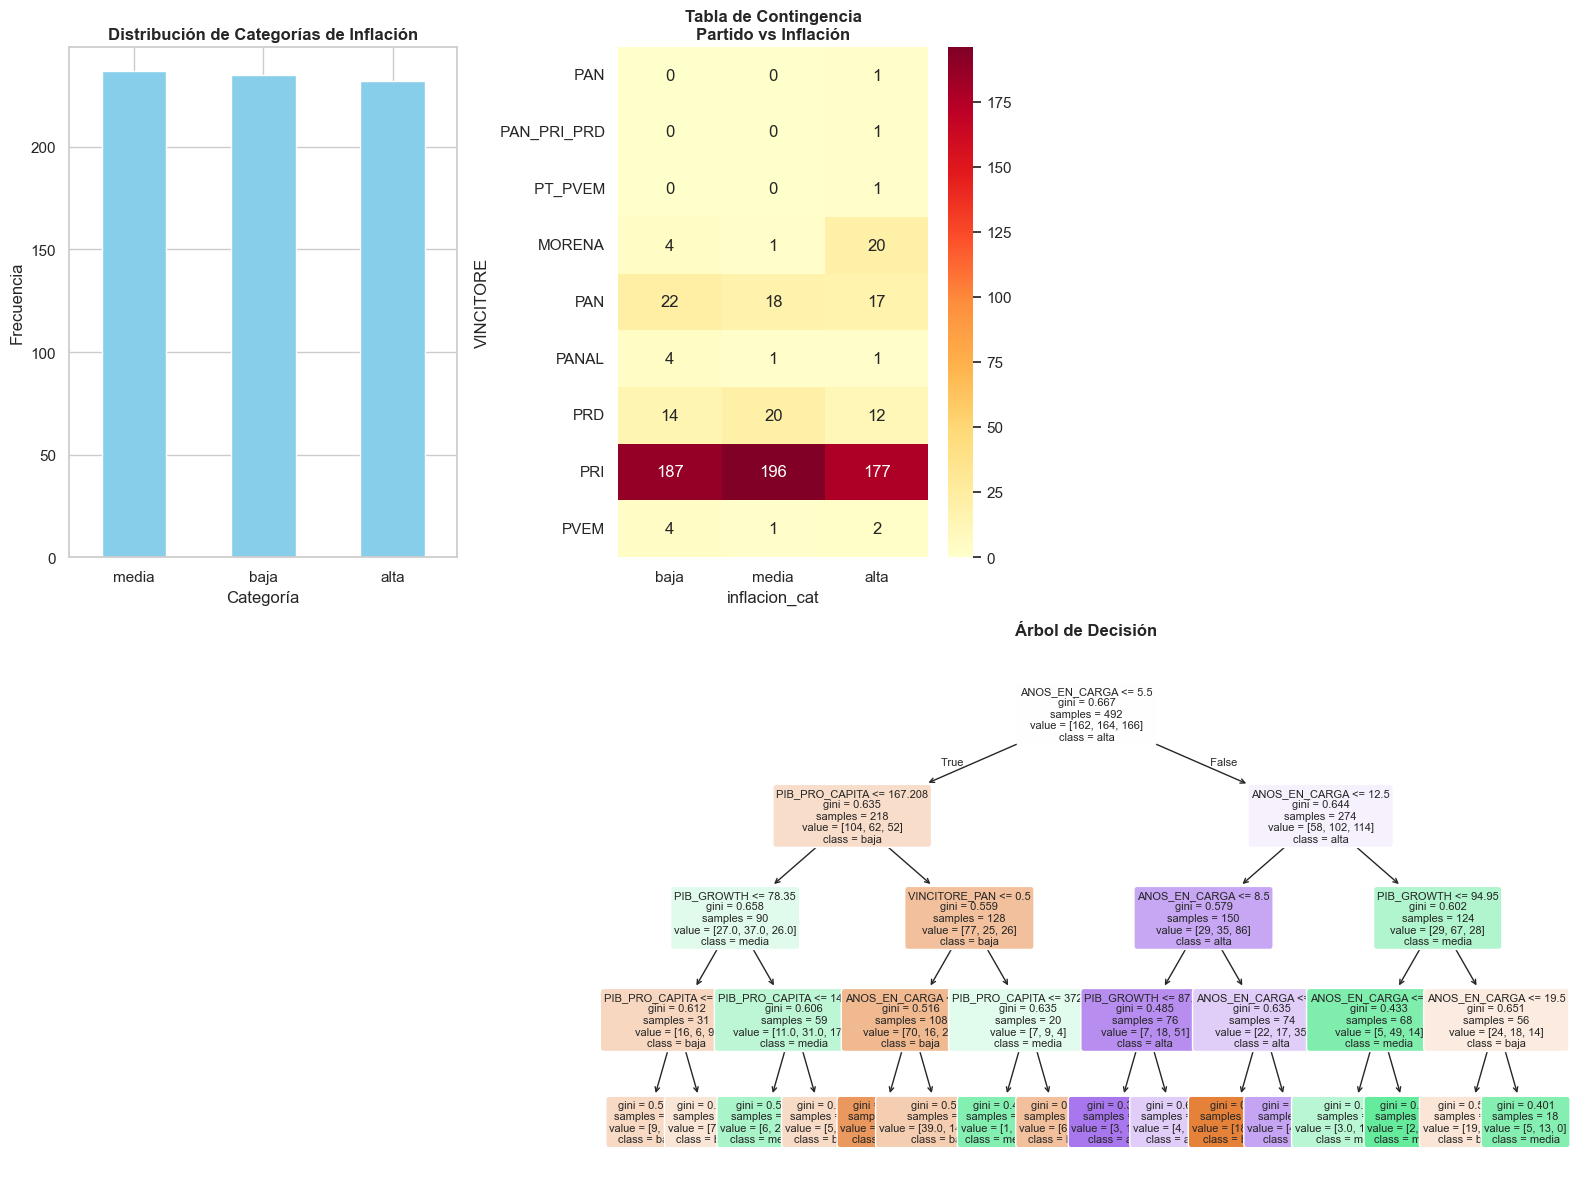


✓ ANÁLISIS COMPLETADO


In [10]:
"""
============================================================
ANÁLISIS INFLACIÓN Y POLÍTICA (2000-2021) - VERSIÓN MEJORADA
- Carga y exploración de datos
- Análisis de asociación (Chi-cuadrada)
- Modelado predictivo (Árbol de decisión)
- Validación y optimización
============================================================
"""

# 1. IMPORTAR LIBRERÍAS
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

# Estadística
from scipy.stats import chi2_contingency

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    ConfusionMatrixDisplay
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


# 2. CARGAR Y EXPLORAR DATOS
# ------------------------------------------------------------
def cargar_datos(ruta):
    """Carga y valida los datos"""
    try:
        df = pd.read_csv(ruta)
        df = df[df["ANNO"] <= 2021].copy()
        print(f"✓ Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")
        return df
    except FileNotFoundError:
        print(f"✗ Archivo no encontrado: {ruta}")
        return None
    except Exception as e:
        print(f"✗ Error al cargar datos: {e}")
        return None


def explorar_datos(df):
    """Resumen exploratorio de los datos"""
    print("\n" + "="*60)
    print("EXPLORACIÓN DE DATOS")
    print("="*60)
    
    print("\n📊 Primeras filas:")
    print(df.head())
    
    print("\n📋 Información general:")
    print(df.info())
    
    print("\n📈 Estadísticas descriptivas:")
    print(df[["INFLACION_ANUAL_ESTADO", "PIB_GROWTH", "PIB_PRO_CAPITA"]].describe())
    
    print("\n🔍 Valores faltantes:")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("✓ No hay valores faltantes")
    
    return df


# 3. CREAR CATEGORÍAS DE INFLACIÓN
# ------------------------------------------------------------
def crear_categorias_inflacion(df):
    """Crea categorías de inflación con percentiles personalizados"""
    # Verificar distribución
    print("\n" + "="*60)
    print("CATEGORIZACIÓN DE INFLACIÓN")
    print("="*60)
    
    inflacion = df["INFLACION_ANUAL_ESTADO"]
    print(f"\nRango de inflación: [{inflacion.min():.2f}, {inflacion.max():.2f}]")
    print(f"Media: {inflacion.mean():.2f}, Mediana: {inflacion.median():.2f}")
    
    # Crear terciles
    df["inflacion_cat"] = pd.qcut(
        inflacion,
        q=3,
        labels=["baja", "media", "alta"],
        duplicates='drop'  # Manejo de duplicados
    )
    
    # Mostrar distribución
    print("\n📊 Distribución por categoría:")
    dist = df["inflacion_cat"].value_counts().sort_index()
    for cat, count in dist.items():
        pct = (count / len(df)) * 100
        print(f"  {cat:6s}: {count:4d} ({pct:5.1f}%)")
    
    # Rangos de inflación por categoría
    print("\n📏 Rangos de inflación por categoría:")
    for cat in ["baja", "media", "alta"]:
        vals = df[df["inflacion_cat"] == cat]["INFLACION_ANUAL_ESTADO"]
        print(f"  {cat:6s}: [{vals.min():.2f}, {vals.max():.2f}]")
    
    return df


# 4. ANÁLISIS CHI-CUADRADA
# ------------------------------------------------------------
def analisis_chi_cuadrada(df):
    """Prueba de independencia entre partido político e inflación"""
    print("\n" + "="*60)
    print("ANÁLISIS CHI-CUADRADA")
    print("="*60)
    
    # Tabla de contingencia
    tabla = pd.crosstab(
        df["VINCITORE"], 
        df["inflacion_cat"],
        margins=True,
        margins_name="Total"
    )
    
    print("\n📊 Tabla de contingencia:")
    print(tabla)
    
    # Chi-cuadrada (sin márgenes)
    tabla_sin_margenes = pd.crosstab(df["VINCITORE"], df["inflacion_cat"])
    chi2, p, dof, expected = chi2_contingency(tabla_sin_margenes)
    
    print("\n📈 Resultados de la prueba:")
    print(f"  Chi-cuadrado (χ²) : {chi2:.4f}")
    print(f"  Grados de libertad: {dof}")
    print(f"  p-valor          : {p:.6f}")
    
    # Interpretación
    alpha = 0.05
    print(f"\n💡 Interpretación (α = {alpha}):")
    if p < alpha:
        print(f"  ✓ Rechazamos H₀ (p={p:.4f} < {alpha})")
        print("  → Existe asociación significativa entre partido e inflación")
    else:
        print(f"  ✗ No rechazamos H₀ (p={p:.4f} >= {alpha})")
        print("  → No hay evidencia de asociación significativa")
    
    # Frecuencias esperadas
    print("\n📋 Frecuencias esperadas bajo H₀:")
    expected_df = pd.DataFrame(
        expected,
        index=tabla_sin_margenes.index,
        columns=tabla_sin_margenes.columns
    )
    print(expected_df.round(2))
    
    # Residuales estandarizados
    residuales = (tabla_sin_margenes - expected_df) / np.sqrt(expected_df)
    print("\n📊 Residuales estandarizados:")
    print(residuales.round(2))
    
    return tabla_sin_margenes


# 5. PREPARAR DATOS PARA MODELADO
# ------------------------------------------------------------
def preparar_datos(df):
    """Prepara features y target para el modelo"""
    print("\n" + "="*60)
    print("PREPARACIÓN DE DATOS")
    print("="*60)
    
    # Target
    y = df["inflacion_cat"]
    
    # Features
    features = [
        "VINCITORE",
        "CAMBIO_PARTIDO",
        "ANOS_EN_CARGA",
        "PIB_GROWTH",
        "PIB_PRO_CAPITA"
    ]
    
    X = df[features].copy()
    
    # Convertir categóricas
    X["VINCITORE"] = X["VINCITORE"].astype("category")
    X["CAMBIO_PARTIDO"] = X["CAMBIO_PARTIDO"].astype("category")
    
    # One-hot encoding
    X_encoded = pd.get_dummies(X, drop_first=True)
    
    print(f"\n✓ Features: {list(X.columns)}")
    print(f"✓ Features después de encoding: {list(X_encoded.columns)}")
    print(f"✓ Dimensiones: {X_encoded.shape}")
    
    return X_encoded, y


# 6. ENTRENAR ÁRBOL DE DECISIÓN
# ------------------------------------------------------------
def entrenar_arbol(X, y):
    """Entrena y evalúa árbol de decisión con validación cruzada"""
    print("\n" + "="*60)
    print("MODELADO: ÁRBOL DE DECISIÓN")
    print("="*60)
    
    # Split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.3, 
        random_state=123, 
        stratify=y
    )
    
    print(f"\n📊 División de datos:")
    print(f"  Entrenamiento: {X_train.shape[0]} muestras")
    print(f"  Prueba       : {X_test.shape[0]} muestras")
    
    # Modelo inicial
    arbol = DecisionTreeClassifier(
        criterion="gini",
        max_depth=4,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=123
    )
    
    # Entrenamiento
    arbol.fit(X_train, y_train)
    
    # Validación cruzada
    cv_scores = cross_val_score(arbol, X_train, y_train, cv=5, scoring='accuracy')
    print(f"\n📈 Validación cruzada (5-fold):")
    print(f"  Accuracy promedio: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    
    # Evaluación
    y_pred_train = arbol.predict(X_train)
    y_pred_test = arbol.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    print(f"\n🎯 Performance:")
    print(f"  Accuracy entrenamiento: {acc_train:.3f}")
    print(f"  Accuracy prueba       : {acc_test:.3f}")
    print(f"  Diferencia (overfitting): {(acc_train - acc_test):.3f}")
    
    # Reporte detallado
    print("\n📋 Reporte de clasificación (conjunto de prueba):")
    print(classification_report(y_test, y_pred_test))
    
    # Importancia de features
    importancias = pd.DataFrame({
        'Feature': X.columns,
        'Importancia': arbol.feature_importances_
    }).sort_values('Importancia', ascending=False)
    
    print("\n🔑 Importancia de features:")
    print(importancias.to_string(index=False))
    
    return arbol, X_train, X_test, y_train, y_test


# 7. OPTIMIZACIÓN DE HIPERPARÁMETROS
# ------------------------------------------------------------
def optimizar_arbol(X_train, y_train):
    """Búsqueda de mejores hiperparámetros"""
    print("\n" + "="*60)
    print("OPTIMIZACIÓN DE HIPERPARÁMETROS")
    print("="*60)
    
    param_grid = {
        'max_depth': [3, 4, 5, 6],
        'min_samples_split': [10, 20, 30],
        'min_samples_leaf': [5, 10, 15],
        'criterion': ['gini', 'entropy']
    }
    
    grid_search = GridSearchCV(
        DecisionTreeClassifier(random_state=123),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    print("\n🔍 Buscando mejores parámetros...")
    grid_search.fit(X_train, y_train)
    
    print(f"\n✓ Mejores parámetros encontrados:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")
    
    print(f"\n📈 Mejor accuracy CV: {grid_search.best_score_:.3f}")
    
    return grid_search.best_estimator_


# 8. VISUALIZACIONES
# ------------------------------------------------------------
def crear_visualizaciones(df, tabla_chi, arbol, X, y_test, y_pred_test):
    """Genera visualizaciones del análisis"""
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Distribución de inflación
    ax1 = plt.subplot(2, 3, 1)
    df["inflacion_cat"].value_counts().plot(kind='bar', color='skyblue', ax=ax1)
    ax1.set_title('Distribución de Categorías de Inflación', fontweight='bold')
    ax1.set_xlabel('Categoría')
    ax1.set_ylabel('Frecuencia')
    plt.xticks(rotation=0)
    
    # 2. Heatmap Chi-cuadrada
    ax2 = plt.subplot(2, 3, 2)
    sns.heatmap(tabla_chi, annot=True, fmt='d', cmap='YlOrRd', ax=ax2)
    ax2.set_title('Tabla de Contingencia\nPartido vs Inflación', fontweight='bold')
    
    

    
    # 3. Árbol de decisión
    ax5 = plt.subplot(2, 3, (5, 6))
    plot_tree(
        arbol,
        feature_names=X.columns,
        class_names=['baja', 'media', 'alta'],
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax5
    )
    ax5.set_title('Árbol de Decisión', fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()


# 9. FUNCIÓN PRINCIPAL
# ------------------------------------------------------------
def main():
    """Ejecuta el análisis completo"""
    # Configurar ruta
    ruta = "/Users/josemiguelalameda/Downloads/tabla_general_2000_2021_imputada.csv"
    
    # Pipeline de análisis
    df = cargar_datos(ruta)
    if df is None:
        return
    
    df = explorar_datos(df)
    df = crear_categorias_inflacion(df)
    tabla_chi = analisis_chi_cuadrada(df)
    X, y = preparar_datos(df)
    arbol, X_train, X_test, y_train, y_test = entrenar_arbol(X, y)
    
    # Opcional: optimizar
    # arbol_opt = optimizar_arbol(X_train, y_train)
    
    # Predicciones para visualización
    y_pred_test = arbol.predict(X_test)
    
    # Visualizaciones
    crear_visualizaciones(df, tabla_chi, arbol, X, y_test, y_pred_test)
    
    print("\n" + "="*60)
    print("✓ ANÁLISIS COMPLETADO")
    print("="*60)


# EJECUTAR
if __name__ == "__main__":
    main()


In [8]:
"""
ANÁLISIS CHI-CUADRADA SIMPLIFICADO
Solo muestra los resultados esenciales
"""

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Cargar datos
df = pd.read_csv("/Users/josemiguelalameda/Downloads/tabla_general_2000_2021_imputada.csv")
df = df[df["ANNO"] <= 2021].copy()

print("="*70)
print(" ANÁLISIS CHI-CUADRADA: PARTIDO vs INFLACIÓN")
print("="*70)

# Crear categorías de inflación
df["inflacion_cat"] = pd.qcut(
    df["INFLACION_ANUAL_ESTADO"],
    q=3,
    labels=["baja", "media", "alta"],
    duplicates='drop'
)

print("\n📊 DISTRIBUCIÓN DE INFLACIÓN POR CATEGORÍA:")
print("-" * 70)
for cat in ["baja", "media", "alta"]:
    n = (df["inflacion_cat"] == cat).sum()
    pct = (n / len(df)) * 100
    rango_inf = df[df["inflacion_cat"] == cat]["INFLACION_ANUAL_ESTADO"]
    print(f"{cat.upper():8s}: {n:3d} casos ({pct:5.1f}%) - Rango: [{rango_inf.min():.2f}%, {rango_inf.max():.2f}%]")

# Tabla de contingencia
print("\n📋 TABLA DE CONTINGENCIA: VINCITORE vs INFLACIÓN")
print("-" * 70)
tabla = pd.crosstab(df["VINCITORE"], df["inflacion_cat"], margins=True)
print(tabla)

# Chi-cuadrada (sin márgenes)
tabla_limpia = pd.crosstab(df["VINCITORE"], df["inflacion_cat"])
chi2, p_valor, gl, esperadas = chi2_contingency(tabla_limpia)

print("\n" + "="*70)
print(" RESULTADOS DE LA PRUEBA CHI-CUADRADA")
print("="*70)
print(f"\n  Estadístico Chi-cuadrado (χ²): {chi2:.4f}")
print(f"  Grados de libertad (gl)      : {gl}")
print(f"  P-valor                      : {p_valor:.6f}")

# Interpretación
print("\n" + "="*70)
print(" INTERPRETACIÓN")
print("="*70)

alpha = 0.05
print(f"\nNivel de significancia: α = {alpha}")

if p_valor < alpha:
    print(f"\n✅ RESULTADO: p-valor ({p_valor:.6f}) < α ({alpha})")
    print("\n   ➜ RECHAZAMOS la hipótesis nula (H₀)")
    print("\n   ➜ CONCLUSIÓN: **SÍ EXISTE ASOCIACIÓN SIGNIFICATIVA**")
    print("      entre el partido político y el nivel de inflación")
    print("\n   ➜ Esto significa que el nivel de inflación NO es")
    print("      independiente del partido que gobierna")
else:
    print(f"\n❌ RESULTADO: p-valor ({p_valor:.6f}) ≥ α ({alpha})")
    print("\n   ➜ NO RECHAZAMOS la hipótesis nula (H₀)")
    print("\n   ➜ CONCLUSIÓN: **NO HAY EVIDENCIA DE ASOCIACIÓN SIGNIFICATIVA**")
    print("      entre el partido político y el nivel de inflación")
    print("\n   ➜ Esto significa que el nivel de inflación parece ser")
    print("      independiente del partido que gobierna")

# Frecuencias esperadas
print("\n" + "="*70)
print(" FRECUENCIAS ESPERADAS (bajo H₀ de independencia)")
print("="*70)
esperadas_df = pd.DataFrame(
    esperadas,
    index=tabla_limpia.index,
    columns=tabla_limpia.columns
)
print(esperadas_df.round(2))

# Residuales estandarizados
print("\n" + "="*70)
print(" RESIDUALES ESTANDARIZADOS")
print("="*70)
print("(Valores > 2 o < -2 indican desviación significativa)")
print("-" * 70)
residuales = (tabla_limpia - esperadas_df) / np.sqrt(esperadas_df)
print(residuales.round(2))

# Análisis de residuales
print("\n📌 ANÁLISIS DE RESIDUALES:")
print("-" * 70)
for partido in tabla_limpia.index:
    for categoria in tabla_limpia.columns:
        res = residuales.loc[partido, categoria]
        obs = tabla_limpia.loc[partido, categoria]
        esp = esperadas_df.loc[partido, categoria]
        
        if abs(res) > 2:
            direccion = "MÁS" if res > 0 else "MENOS"
            print(f"  • {partido} - {categoria}: residual = {res:.2f}")
            print(f"    → {direccion} casos de lo esperado (Obs: {obs}, Esp: {esp:.1f})")

print("\n" + "="*70)
print(" ANÁLISIS COMPLETADO")
print("="*70)

 ANÁLISIS CHI-CUADRADA: PARTIDO vs INFLACIÓN

📊 DISTRIBUCIÓN DE INFLACIÓN POR CATEGORÍA:
----------------------------------------------------------------------
BAJA    : 235 casos ( 33.4%) - Rango: [0.07%, 3.40%]
MEDIA   : 237 casos ( 33.7%) - Rango: [3.40%, 4.34%]
ALTA    : 232 casos ( 33.0%) - Rango: [4.34%, 9.21%]

📋 TABLA DE CONTINGENCIA: VINCITORE vs INFLACIÓN
----------------------------------------------------------------------
inflacion_cat  baja  media  alta  All
VINCITORE                            
 PAN              0      0     1    1
 PAN_PRI_PRD      0      0     1    1
 PT_PVEM          0      0     1    1
MORENA            4      1    20   25
PAN              22     18    17   57
PANAL             4      1     1    6
PRD              14     20    12   46
PRI             187    196   177  560
PVEM              4      1     2    7
All             235    237   232  704

 RESULTADOS DE LA PRUEBA CHI-CUADRADA

  Estadístico Chi-cuadrado (χ²): 40.0931
  Grados de libertad (gl

Dimensiones de la base (2000–2021): (704, 9)
Primeras filas:


,ANNO,ENTIDAD,VINCITORE,CAMBIO_PARTIDO,ANOS_EN_CARGA,INFLACION_ANUAL_ESTADO,PIB,PIB_GROWTH,PIB_PRO_CAPITA
0,2000,AGUASCALIENTES,PRI,0.0,1.0,9.207048,158300000.0,48.2,167.640066
1,2000,BAJA CALIFORNIA,PRI,0.0,1.0,7.254236,790647000.0,90.0,837.297002
2,2000,BAJA CALIFORNIA SUR,PRI,0.0,1.0,8.536065,95187000.0,51.6,100.803253
3,2000,CAMPECHE,PRI,0.0,1.0,7.953773,826278000.0,147.9,875.030314
4,2000,CHIAPAS,PRD,0.0,1.0,8.075211,309797000.0,87.2,328.075740



Variables usadas en PCA:
                        count          mean           std           min  \
INFLACION_ANUAL_ESTADO  704.0  4.153103e+00  1.517211e+00  6.655258e-02   
PIB                     704.0  6.124849e+08  5.934158e+08  9.518700e+07   
PIB_GROWTH              704.0  8.660733e+01  1.653841e+01  4.770000e+01   
PIB_PRO_CAPITA          704.0  3.100619e+02  4.602062e+02  8.295476e+00   
ANOS_EN_CARGA           704.0  8.011364e+00  6.264205e+00  1.000000e+00   

                                 25%           50%           75%           max  
INFLACION_ANUAL_ESTADO  3.148523e+00  3.694120e+00  4.836691e+00  9.207048e+00  
PIB                     2.693292e+08  4.517400e+08  7.268468e+08  3.694575e+09  
PIB_GROWTH              7.615000e+01  8.710000e+01  9.670000e+01  1.785000e+02  
PIB_PRO_CAPITA          8.028675e+01  1.684805e+02  3.380762e+02  5.459260e+03  
ANOS_EN_CARGA           2.000000e+00  7.000000e+00  1.300000e+01  2.200000e+01  

Varianza explicada por componente:
P

,INFLACION_ANUAL_ESTADO,PIB,PIB_GROWTH,PIB_PRO_CAPITA,ANOS_EN_CARGA
PC1,-0.027056,0.698632,0.237684,0.658220,0.146407
PC2,-0.575995,-0.054259,0.471197,-0.271455,0.607923
PC3,0.623961,-0.142453,0.761739,-0.086929,-0.050759
PC4,0.513660,-0.013847,-0.372036,-0.001787,0.773012
PC5,0.119680,0.698917,-0.053120,-0.696778,-0.094183


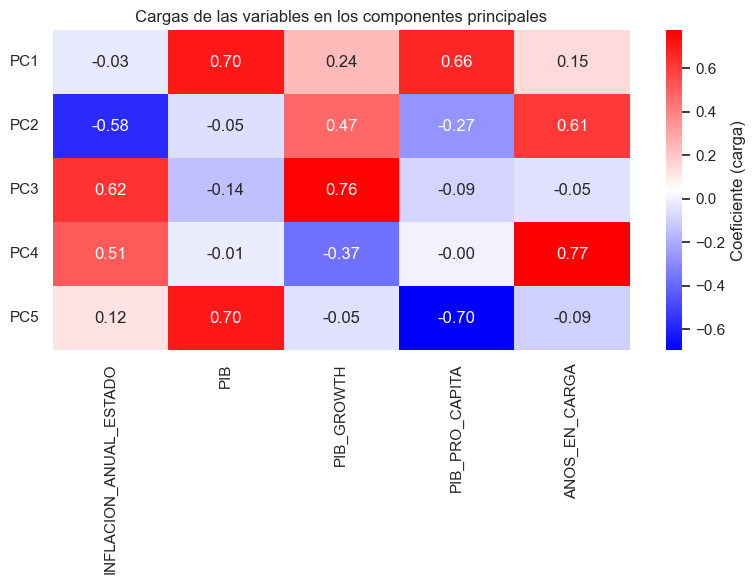


Primeras filas de las proyecciones (PCs + partido):


,PC1,PC2,PC3,PC4,PC5,VINCITORE
0,-1.545484,-3.570384,0.502569,1.722185,0.308363,PRI
1,0.793992,-2.089857,1.347031,0.102242,-0.249462,PRI
2,-1.654631,-3.173304,0.410934,1.420054,0.271348,PRI
3,1.710204,-0.730345,4.287931,-0.965138,-0.395521,PRI
4,-0.556279,-2.137007,1.767613,0.456623,0.029140,PRD


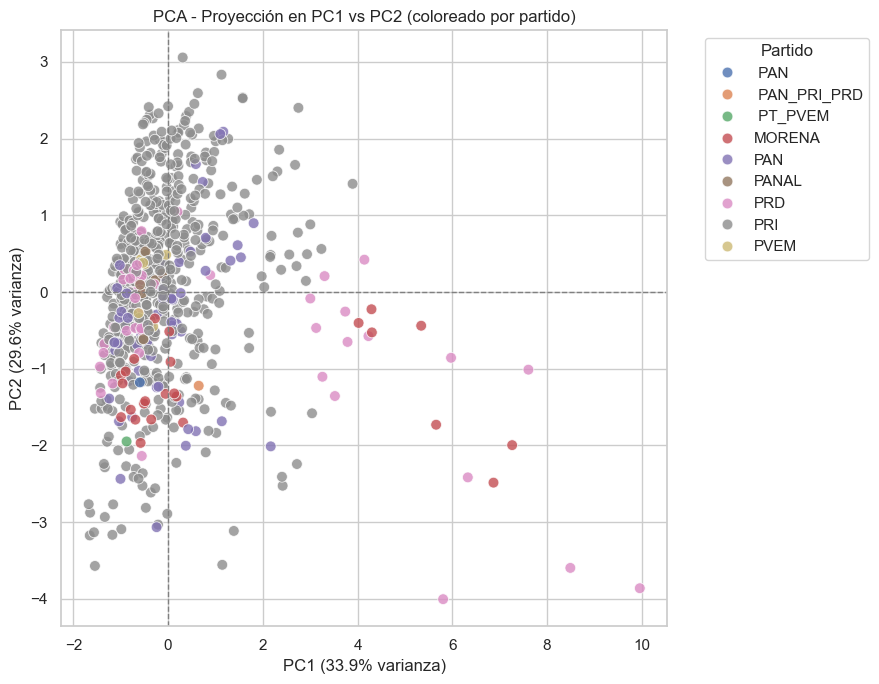

In [9]:
# ============================================================
#  PCA - PROYECTO: INFLACIÓN Y PARTIDOS POLÍTICOS (2000–2021)
#  - Carga de datos
#  - Selección de variables numéricas
#  - PCA con estandarización (pipeline)
#  - Heatmap de componentes
#  - Visualización en R^2 (PC1 vs PC2) coloreando por partido
# ============================================================

# 1. IMPORTAR LIBRERÍAS
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

# Estilo de gráficos
sns.set(style="whitegrid", context="notebook")

# 2. CARGAR BASE DE DATOS
# ------------------------------------------------------------
# Usa la ruta que me diste:
ruta = "/Users/josemiguelalameda/Downloads/tabla_general_2000_2021_imputada.csv"
df = pd.read_csv(ruta)

# Nos aseguramos que sólo esté 2000–2021 (por si el archivo tiene más años)
df = df[df["ANNO"] <= 2021].copy()

print("Dimensiones de la base (2000–2021):", df.shape)
print("Primeras filas:")
display(df.head())

# 3. SELECCIONAR VARIABLES NUMÉRICAS PARA PCA
# ------------------------------------------------------------
# Variables que resumen inflación y contexto económico/político
cols = [
    "INFLACION_ANUAL_ESTADO",
    "PIB",
    "PIB_GROWTH",
    "PIB_PRO_CAPITA",
    "ANOS_EN_CARGA"
    # Si quieres, puedes agregar CAMBIO_PARTIDO si es 0/1:
    # "CAMBIO_PARTIDO"
]

X = df[cols].copy()

print("\nVariables usadas en PCA:")
print(X.describe().T)

# 4. ENTRENAR PCA CON ESTANDARIZACIÓN (PIPELINE)
# ------------------------------------------------------------
# PCA con todos los componentes (n_components=None)
# luego usaremos PC0 y PC1 para la visualización en R^2

pca_pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=None)  # tantas componentes como variables
)

pca_pipe.fit(X)

# Extraer el modelo PCA entrenado
modelo_pca = pca_pipe.named_steps["pca"]
componentes = modelo_pca.components_     # matriz de cargas
var_explicada = modelo_pca.explained_variance_ratio_

print("\nVarianza explicada por componente:")
for i, v in enumerate(var_explicada):
    print(f"PC{i+1}: {v:.4f} ({v*100:.2f}%)")

# Matriz de componentes (cargas de cada variable en cada PC)
df_componentes = pd.DataFrame(
    data    = componentes,
    columns = X.columns,
    index   = [f"PC{i+1}" for i in range(len(X.columns))]
)

print("\nComponentes principales (cargas):")
display(df_componentes)

# 5. HEATMAP DE LOS COMPONENTES (CARGAS)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_componentes,
    cmap="bwr",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Coeficiente (carga)"}
)
plt.title("Cargas de las variables en los componentes principales")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. PROYECCIÓN DE LAS OBSERVACIONES EN EL ESPACIO DE PCA
# ------------------------------------------------------------
# Transformar X al espacio de componentes principales
proyecciones = pca_pipe.transform(X)

proyecciones = pd.DataFrame(
    proyecciones,
    columns=[f"PC{i+1}" for i in range(len(X.columns))],
    index=X.index
)

# Agregamos el partido para poder colorear el scatter
proyecciones["VINCITORE"] = df["VINCITORE"].astype("category")

print("\nPrimeras filas de las proyecciones (PCs + partido):")
display(proyecciones.head())

# 7. VISUALIZACIÓN EN R^2: PC1 vs PC2 COLOREADO POR PARTIDO
# ------------------------------------------------------------
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=proyecciones,
    x="PC1",
    y="PC2",
    hue="VINCITORE",
    alpha=0.8,
    s=60
)
plt.axhline(0, color="grey", linewidth=1, linestyle="--")
plt.axvline(0, color="grey", linewidth=1, linestyle="--")
plt.title("PCA - Proyección en PC1 vs PC2 (coloreado por partido)")
plt.xlabel(f"PC1 ({var_explicada[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({var_explicada[1]*100:.1f}% varianza)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Partido")
plt.tight_layout()
plt.show()
